## Introducción

En este proyecto práctico se entrena un modelo de detección de objetos utilizando YOLOv8, con el dataset COCO y una cantidad reducida de imágenes (val2017, 300 imágenes). Se realizan transformaciones con Albumentations, conversión de anotaciones de formato COCO a YOLO y visualización de ejemplos aumentados, siguiendo la metodología propuesta en las clases 3 y 4 del módulo.

### 1. Preparación del Entorno: Instalación de librerías.

In [1]:
# Instalar la biblioteca YOLOv8
!pip install ultralytics --quiet

# Instalar OpenCV para trabajar con imágenes
!pip install opencv-python --quiet

# Instalar albumentations para aumentar datos
!pip install albumentations --quiet

# Instalar matplotlib para mostrar imágenes
!pip install matplotlib --quiet

# Instalar PyYAML (requisito interno de YOLO)
!pip install pyyaml --quiet

# Instalar scikit-learn
!pip install scikit-learn --quiet

In [2]:
# Importar bibliotecas necesarias
import os
import urllib.request
import zipfile
import shutil 
from sklearn.model_selection import train_test_split
import json
from tqdm import tqdm
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
import random
import shutil 
from sklearn.model_selection import train_test_split
from ultralytics import YOLO

### 2. Recolección de Datos: Descarga y descompresión del dataset COCO. 

In [3]:
# Crear carpeta para el dataset si no existe
os.makedirs("data", exist_ok=True)

# Definir URLs de descarga
url_images = "http://images.cocodataset.org/zips/val2017.zip"
url_annotations = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"

# Definir rutas de destino
ruta_img_zip = "data/val2017.zip"
ruta_ann_zip = "data/annotations_trainval2017.zip"

# Descargar imágenes del conjunto de validación
print("Descargando imágenes...")
urllib.request.urlretrieve(url_images, ruta_img_zip)

# Descargar anotaciones
print("Descargando anotaciones...")
urllib.request.urlretrieve(url_annotations, ruta_ann_zip)

# Extraer archivos ZIP
print("Extrayendo imágenes...")
with zipfile.ZipFile(ruta_img_zip, 'r') as zip_ref:
    zip_ref.extractall("data")

print("Extrayendo anotaciones...")
with zipfile.ZipFile(ruta_ann_zip, 'r') as zip_ref:
    zip_ref.extractall("data")


Descargando imágenes...
Descargando anotaciones...
Extrayendo imágenes...
Extrayendo anotaciones...


In [4]:
# Crear carpetas para dataset formateado
base = "data/dataset_yolo"
os.makedirs(f"{base}/images/train", exist_ok=True)
os.makedirs(f"{base}/images/val", exist_ok=True)
os.makedirs(f"{base}/labels/train", exist_ok=True)
os.makedirs(f"{base}/labels/val", exist_ok=True)

# Obtener lista de imágenes aumentadas
imagenes = os.listdir("data/val2017_aug")
imagenes = [img for img in imagenes if img.endswith(".jpg")]

# Separar 80% treino, 20% validação
train_imgs, val_imgs = train_test_split(imagenes, test_size=0.2, random_state=42)

# Copiar archivos
for img in train_imgs:
    shutil.copy(f"data/val2017_aug/{img}", f"{base}/images/train/{img}")
    shutil.copy(f"data/labels_val2017_aug/{img.replace('.jpg', '.txt')}", f"{base}/labels/train/{img.replace('.jpg', '.txt')}")

for img in val_imgs:
    shutil.copy(f"data/val2017_aug/{img}", f"{base}/images/val/{img}")
    shutil.copy(f"data/labels_val2017_aug/{img.replace('.jpg', '.txt')}", f"{base}/labels/val/{img.replace('.jpg', '.txt')}")


### 3. Conversión de Anotaciones: Conversión de anotaciones de COCO a YOLO. 

In [5]:
# Ruta de las anotaciones COCO
ruta_json = "data/annotations/instances_val2017.json"

# Cargar anotaciones COCO
with open(ruta_json, "r") as archivo:
    datos = json.load(archivo)

# Crear diccionario de categorías
categorias = {cat["id"]: cat["name"] for cat in datos["categories"]}

# Crear diccionario de anotaciones por imagen
anotaciones_por_imagen = {}
for ann in datos["annotations"]:
    img_id = ann["image_id"]
    if img_id not in anotaciones_por_imagen:
        anotaciones_por_imagen[img_id] = []
    anotaciones_por_imagen[img_id].append(ann)

# Crear diccionario de imágenes
imagenes = {img["id"]: img for img in datos["images"]}

# Carpeta de salida para etiquetas YOLO
salida_labels = "data/labels_val2017"
os.makedirs(salida_labels, exist_ok=True)

# Convertir anotaciones COCO a formato YOLO
for img_id, anotaciones in tqdm(anotaciones_por_imagen.items()):
    img_info = imagenes[img_id]
    w = img_info["width"]
    h = img_info["height"]
    nombre_img = img_info["file_name"]
    nombre_txt = nombre_img.replace(".jpg", ".txt")
    ruta_salida = os.path.join(salida_labels, nombre_txt)

    with open(ruta_salida, "w") as archivo_txt:
        for ann in anotaciones:
            bbox = ann["bbox"]  # formato COCO: [x_min, y_min, width, height]
            x_c = (bbox[0] + bbox[2] / 2) / w
            y_c = (bbox[1] + bbox[3] / 2) / h
            ancho = bbox[2] / w
            alto = bbox[3] / h
            clase = ann["category_id"] - 1  # YOLO usa índices desde 0

            # Escribir línea en formato YOLO
            archivo_txt.write(f"{clase} {x_c:.6f} {y_c:.6f} {ancho:.6f} {alto:.6f}\n")


100%|██████████| 4952/4952 [00:01<00:00, 3307.54it/s]


### 4. Transformación y Aumento de Datos: Normalización y aumento de datos usando Albumentations. 

In [6]:
# Crear carpetas de salida
os.makedirs("data/val2017_aug", exist_ok=True)
os.makedirs("data/labels_val2017_aug", exist_ok=True)

# Definir transformaciones y configuración de cajas
transformaciones = A.Compose([
    A.HorizontalFlip(p=0.5),              # Girar horizontalmente con 50% de probabilidad
    A.RandomBrightnessContrast(p=0.5),    # Cambiar brillo y contraste aleatoriamente
    A.Rotate(limit=15, p=0.5),            # Rotar imagen hasta 15 grados
    A.Resize(640, 640),                   # Redimensionar a 640x640
], bbox_params=A.BboxParams(
    format='yolo', 
    label_fields=['class_labels'], 
    min_visibility=0.1,                  # Ignorar cajas muy pequeñas
    check_each_transform=True            # Validar cada transformación
))

# Obtener lista de archivos de anotaciones
archivos = os.listdir("data/labels_val2017")

# Aplicar transformaciones a un subconjunto (ejemplo: 300 imágenes)
for archivo_txt in tqdm(archivos[:300]):
    ruta_txt = os.path.join("data/labels_val2017", archivo_txt)
    nombre_img = archivo_txt.replace(".txt", ".jpg")
    ruta_img = os.path.join("data/val2017", nombre_img)

    # Leer imagen
    imagen = cv2.imread(ruta_img)
    if imagen is None:
        continue
    h, w, _ = imagen.shape

    # Leer anotaciones YOLO
    bboxes = []
    class_labels = []
    with open(ruta_txt, "r") as f:
        for linea in f:
            clase, x, y, ancho, alto = map(float, linea.strip().split())
            bboxes.append([x, y, ancho, alto])
            class_labels.append(int(clase))

    # Saltar si no hay cajas
    if not bboxes:
        continue

    # Intentar aplicar transformaciones (manejar errores silenciosamente)
    try:
        transformado = transformaciones(
            image=imagen,
            bboxes=bboxes,
            class_labels=class_labels
        )
    except Exception as e:
        continue  # Saltar esta imagen si hay problema con la transformación

    imagen_aug = transformado['image']
    bboxes_aug = transformado['bboxes']
    class_labels_aug = transformado['class_labels']

    # Saltar si no hay cajas válidas tras la transformación
    if not bboxes_aug:
        continue

    # Guardar imagen transformada
    ruta_img_salida = os.path.join("data/val2017_aug", nombre_img)
    cv2.imwrite(ruta_img_salida, imagen_aug)

    # Guardar anotaciones transformadas
    ruta_txt_salida = os.path.join("data/labels_val2017_aug", archivo_txt)
    with open(ruta_txt_salida, "w") as f_out:
        for bbox, clase in zip(bboxes_aug, class_labels_aug):
            f_out.write(f"{clase} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n")

100%|██████████| 300/300 [00:03<00:00, 75.79it/s]


 Visualizar imagenes

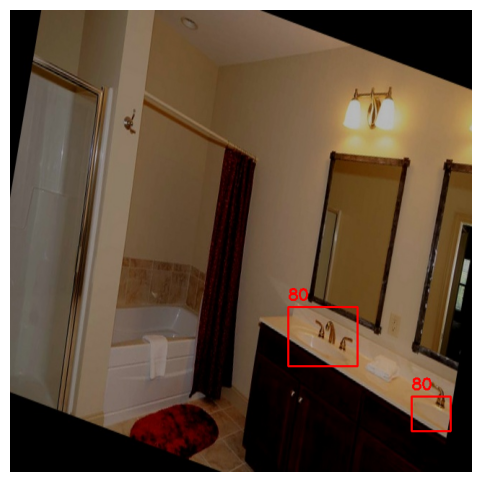

In [7]:
# Función para visualizar una imagen con sus cajas
def mostrar_imagen_con_cajas(ruta_img, ruta_txt):
    imagen = cv2.imread(ruta_img)
    imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)  # Convertir BGR a RGB
    h, w, _ = imagen.shape

    # Leer las cajas
    cajas = []
    with open(ruta_txt, "r") as f:
        for linea in f:
            clase, x, y, ancho, alto = map(float, linea.strip().split())
            # Convertir coordenadas normalizadas a píxeles
            x1 = int((x - ancho/2) * w)
            y1 = int((y - alto/2) * h)
            x2 = int((x + ancho/2) * w)
            y2 = int((y + alto/2) * h)
            cajas.append((x1, y1, x2, y2, int(clase)))

    # Dibujar cajas
    for x1, y1, x2, y2, clase in cajas:
        cv2.rectangle(imagen, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(imagen, str(clase), (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

    # Mostrar imagen
    plt.figure(figsize=(6,6))
    plt.imshow(imagen)
    plt.axis('off')
    plt.show()

# Elegir una imagen aumentada aleatoria
archivo = random.choice(os.listdir("data/val2017_aug"))
ruta_img_ejemplo = os.path.join("data/val2017_aug", archivo)
ruta_txt_ejemplo = os.path.join("data/labels_val2017_aug", archivo.replace(".jpg", ".txt"))

# Mostrar imagen con cajas
mostrar_imagen_con_cajas(ruta_img_ejemplo, ruta_txt_ejemplo)

### 5. Entrenamiento del Modelo: Configuración y entrenamiento del modelo YOLOv8. 

In [8]:
# Crear carpetas para dataset formateado
base = "data/dataset_yolo"
os.makedirs(f"{base}/images/train", exist_ok=True)
os.makedirs(f"{base}/images/val", exist_ok=True)
os.makedirs(f"{base}/labels/train", exist_ok=True)
os.makedirs(f"{base}/labels/val", exist_ok=True)

# Obtener lista de imágenes aumentadas
imagenes = os.listdir("data/val2017_aug")
imagenes = [img for img in imagenes if img.endswith(".jpg")]

# Separar 80% treino, 20% validação
train_imgs, val_imgs = train_test_split(imagenes, test_size=0.2, random_state=42)

# Copiar archivos
for img in train_imgs:
    shutil.copy(f"data/val2017_aug/{img}", f"{base}/images/train/{img}")
    shutil.copy(f"data/labels_val2017_aug/{img.replace('.jpg', '.txt')}", f"{base}/labels/train/{img.replace('.jpg', '.txt')}")

for img in val_imgs:
    shutil.copy(f"data/val2017_aug/{img}", f"{base}/images/val/{img}")
    shutil.copy(f"data/labels_val2017_aug/{img.replace('.jpg', '.txt')}", f"{base}/labels/val/{img.replace('.jpg', '.txt')}")


In [ ]:
# Cargar modelo YOLOv8 preentrenado
modelo = YOLO("yolov8n.pt")  # yolov8n = nano, rápido e leve

# Entrenar con nuestros datos
modelo.train(
    data="coco_val300.yaml",
    epochs=10,
    imgsz=416,
    batch=8
)

Ultralytics 8.3.160  Python-3.13.5 torch-2.7.1+cpu CPU (AMD Ryzen 7 7700 8-Core Processor)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco_val300.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=True,

train: Scanning C:\Users\nunoc\OneDrive\Área de Trabalho\MIA\Computer Vision\u2\data\dataset_yolo\labels\train... 225 images, 0 backgrounds, 33 corrupt: 100%|██████████| 225/225 [00:00<00:00, 1557.01it/s]

train: C:\Users\nunoc\OneDrive\rea de Trabalho\MIA\Computer Vision\u2\data\dataset_yolo\images\train\000000000139.jpg: ignoring corrupt image/label: Label class 85 exceeds dataset class count 80. Possible class labels are 0-79
train: C:\Users\nunoc\OneDrive\rea de Trabalho\MIA\Computer Vision\u2\data\dataset_yolo\images\train\000000000632.jpg: ignoring corrupt image/label: Label class 83 exceeds dataset class count 80. Possible class labels are 0-79
train: C:\Users\nunoc\OneDrive\rea de Trabalho\MIA\Computer Vision\u2\data\dataset_yolo\images\train\000000000776.jpg: ignoring corrupt image/label: Label class 87 exceeds dataset class count 80. Possible class labels are 0-79
train: C:\Users\nunoc\OneDrive\rea de Trabalho\MIA\Computer Vision\u2\data\dataset_yolo\images\train\000000001296.jpg: ignoring corrupt image/label: Label class 84 exceeds dataset class count 80. Possible class labels are 0-79
train: C:\Users\nunoc\OneDrive\rea de Trabalho\MIA\Computer Vision\u2\data\dataset_yolo\imag


c:\Users\nunoc\OneDrive\Área de Trabalho\MIA\Computer Vision\u2\.venv\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
val: Scanning C:\Users\nunoc\OneDrive\Área de Trabalho\MIA\Computer Vision\u2\data\dataset_yolo\labels\val... 57 images, 0 backgrounds, 11 corrupt: 100%|██████████| 57/57 [00:00<00:00, 1611.69it/s]

val: C:\Users\nunoc\OneDrive\rea de Trabalho\MIA\Computer Vision\u2\data\dataset_yolo\images\val\000000000802.jpg: ignoring corrupt image/label: Label class 81 exceeds dataset class count 80. Possible class labels are 0-79
val: C:\Users\nunoc\OneDrive\rea de Trabalho\MIA\Computer Vision\u2\data\dataset_yolo\images\val\000000005001.jpg: ignoring corrupt image/label: Label class 86 exceeds dataset class count 80. Possible class labels are 0-79
val: C:\Users\nunoc\OneDrive\rea de Trabalho\MIA\Computer Vision\u2\data\dataset_yolo\images\val\000000007818.jpg: ignoring corrupt image/label: Label class 85 exceeds dataset class count 80. Possible class labels are 0-79
val: C:\Users\nunoc\OneDrive\rea de Trabalho\MIA\Computer Vision\u2\data\dataset_yolo\images\val\000000009590.jpg: ignoring corrupt image/label: Label class 84 exceeds dataset class count 80. Possible class labels are 0-79
val: C:\Users\nunoc\OneDrive\rea de Trabalho\MIA\Computer Vision\u2\data\dataset_yolo\images\val\00000000977

...

                   all         46        365       0.52      0.169      0.166       0.12

10 epochs completed in 0.029 hours.
Optimizer stripped from runs\detect\train\weights\last.pt, 6.5MB


Optimizer stripped from runs\detect\train\weights\best.pt, 6.5MB

Validating runs\detect\train\weights\best.pt...
Ultralytics 8.3.160  Python-3.13.5 torch-2.7.1+cpu CPU (AMD Ryzen 7 7700 8-Core Processor)
Model summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:01<00:00,  2.86it/s]


                   all         46        365      0.521      0.169      0.166       0.12
                person         22        123      0.472      0.528       0.51      0.267
                   car          7         28      0.481        0.5      0.523       0.34
                   bus          5          5      0.772        0.6        0.7      0.627
                 train          1          1       0.55          1      0.995      0.895
                 truck          1          2      0.213        0.5      0.173      0.086
                  boat          1          4          0          0     0.0813     0.0218
         traffic light          4          5      0.342        0.2      0.222     0.0306
                   cat          4         12          1          0      0.122     0.0547
                 sheep          1          2          0          0     0.0113    0.00537
                   cow          1          1          0          0     0.0061    0.00183
              elephan

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  2,  5,  6,  7,  8,  9, 15, 18, 19, 20, 21, 23, 24, 26, 30, 31, 32, 33, 36, 37, 38, 39, 40, 41, 42, 43, 45, 46, 47, 48, 49, 50, 51, 55, 58, 59, 60, 61, 62, 66, 69, 71, 72, 73, 75, 76])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001CDAFE0E4E0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034, 

In [ ]:
### 6. Evaluación del Modelo: Evaluación del modelo en el conjunto de validación.

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Obtener nombres de las clases y métricas
class_names = metrics.names
precisions = metrics.box.p.tolist()
recalls = metrics.box.r.tolist()
map50s = metrics.box.map50.tolist()

# Crear gráfico
x = np.arange(len(class_names))
width = 0.25

plt.figure(figsize=(12, 6))
plt.bar(x - width, precisions, width, label='Precisión', color='skyblue')
plt.bar(x, recalls, width, label='Recall', color='lightgreen')
plt.bar(x + width, map50s, width, label='mAP@50', color='salmon')

plt.xlabel('Clases')
plt.ylabel('Métricas')
plt.title('Evaluación del modelo por clase')
plt.xticks(x, class_names, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()


NameError: name 'metrics' is not defined

Debido a limitaciones de hardware (no disponer de GPU), se redujo el conjunto de datos para permitir la ejecución en CPU dentro de un tiempo razonable.

Se instaló el entorno necesario (ultralytics, opencv-python, albumentations, etc.), y se descargaron imágenes del dataset COCO (val2017) junto con sus anotaciones. Luego, se aplicaron transformaciones con Albumentations y se convirtieron las anotaciones del formato COCO al formato YOLO.

Las imágenes se dividieron en entrenamiento y validación (80/20), y se organizó la estructura de carpetas para el modelo. Se utilizó el modelo yolov8n, más ligero, y se entrenó durante 10 épocas. A pesar del número reducido de imágenes, se observó una mejora en las métricas de precisión y recall a lo largo del entrenamiento.

El trabajo avanzó correctamente hasta la etapa 7, incluyendo la inferencia sobre imágenes nuevas. A pesar de las limitaciones técnicas, se logró completar el flujo principal y obtener resultados funcionales.